    # Example 5: Finite-volume simulation of steep thermal fronts in a tubular reactor

This example extends the non-isothermal plug-flow tubular reactor (PFTR) of Example 2. Instead of integrating a steady model along the axial coordinate, the full transient material and energy balances are discretized into finite volumes and integrated in time.

The example illustrates:

1. first-order upwind finite-volume fluxes for a convection-dominated reactor,
2. transient startup and approach to steady state,
3. a deliberately steep Arrhenius case obtained without changing the rate at 440 K,
4. grid convergence and numerical diffusion,
5. local grid refinement, and
6. the use of SciPy's implicit BDF integrator for the resulting stiff ODE system.


In [25]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import lil_matrix

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})


## Model equations

The pseudo-first-order hydrolysis of ethylene oxide (EO) is

$$\mathrm{EO + H_2O \rightarrow EG}, \qquad
r = k(T)c_{\mathrm{EO}}, \qquad
k(T)=k_0\exp\left(-\frac{E_A}{RT}\right).$$

With constant velocity and physical properties, the transient balances are

$$\frac{\partial c_{\mathrm{EO}}}{\partial t}
=-u\frac{\partial c_{\mathrm{EO}}}{\partial z}-r,$$

$$\rho c_p\frac{\partial T}{\partial t}
=-\rho c_pu\frac{\partial T}{\partial z}
-r\Delta_RH-h_wa_w(T-T_C).$$

The inlet values enter as upwind face fluxes. Because there is no axial dispersion, no downstream boundary condition is required. For a control volume of length $\Delta z$, the first-order upwind approximation is

$$\left.\frac{\partial \phi}{\partial z}\right|_i
\approx \frac{\phi_i-\phi_{i-1}}{\Delta z},$$

where the inlet value replaces $\phi_{i-1}$ for the first control volume. This scheme is conservative and robust, but a coarse grid introduces numerical diffusion.


In [26]:
class Parameters:
    def __init__(self, Nz=160, EA=72.5e3, k0=5.01e6):
        # Geometry and flow
        self.L = 300.0              # reactor length / m
        self.d_R = 0.03             # reactor diameter / m
        self.u = 1.0                # fluid velocity / m s^-1
        self.Nz = Nz
        self.dz = self.L / self.Nz
        self.z = (np.arange(self.Nz) + 0.5) * self.dz

        # Physical properties and heat transfer (Example 2)
        self.rho = 1000.0           # kg m^-3
        self.cp = 4190.0            # J kg^-1 K^-1
        self.h_w = 500.0            # W m^-2 K^-1
        self.a_w = 4.0 / self.d_R   # wall area per reactor volume / m^-1
        self.delta_H = -122.2e3      # J mol^-1

        # Inlet and coolant
        self.c_in = 2.27e3          # mol m^-3 (2.27 mol L^-1)
        self.T_in = 423.0           # K
        self.T_C = 440.0            # K

        # Arrhenius parameters
        self.R = 8.314              # J mol^-1 K^-1
        self.k0_reference = 5.01e6  # s^-1
        self.EA_reference = 72.5e3  # J mol^-1
        self.EA = EA                # s^-1
        # self.k0 = k0                # J mol^-1

        # Recalibrate k0 so all kinetic cases have the same k at 440 K.
        self.T_kinetic_reference = 440.0
        k_at_reference = self.k0_reference * np.exp(
            -self.EA_reference / (self.R * self.T_kinetic_reference)
        )
        self.k0 = k_at_reference * np.exp(
            self.EA / (self.R * self.T_kinetic_reference)
        )

        self.t_end = 450.0          # s


def reactor_1d(t, y, p):
    c = y[:p.Nz]
    T = y[p.Nz:]

    # Upwind states at the west face of each finite volume
    c_upwind = np.r_[p.c_in, c[:-1]]
    T_upwind = np.r_[p.T_in, T[:-1]]

    k = p.k0 * np.exp(-p.EA / (p.R * T))
    rate = k * c

    dc_dt = -p.u * (c - c_upwind) / p.dz - rate
    dT_dt = (
        -p.u * (T - T_upwind) / p.dz
        + (-p.delta_H) * rate / (p.rho * p.cp)
        - p.h_w * p.a_w * (T - p.T_C) / (p.rho * p.cp)
    )
    return np.r_[dc_dt, dT_dt]


def jacobian_sparsity_1d(p):
    # Dependencies of the semi-discrete equations, used by BDF.
    n = 2 * p.Nz
    S = lil_matrix((n, n), dtype=int)
    for i in range(p.Nz):
        S[i, i] = 1
        S[i, p.Nz + i] = 1
        S[p.Nz + i, i] = 1
        S[p.Nz + i, p.Nz + i] = 1
        if i > 0:
            S[i, i - 1] = 1
            S[p.Nz + i, p.Nz + i - 1] = 1
    return S.tocsr()


def simulate_1d(p, t_eval=None, method="BDF"):
    y0 = np.r_[
        np.full(p.Nz, p.c_in),
        np.full(p.Nz, p.T_in),
    ]
    options = {}
    if method in ("BDF", "Radau"):
        options["jac_sparsity"] = jacobian_sparsity_1d(p)
    elif method == "BDF_jac_sparse":
        method = "BDF"

    started = time.perf_counter()
    solution = solve_ivp(
        reactor_1d,
        (0.0, p.t_end),
        y0,
        args=(p,),
        method=method,
        t_eval=t_eval,
        rtol=2e-6,
        atol=np.r_[np.full(p.Nz, 1e-3), np.full(p.Nz, 1e-5)],
        **options,
    )
    solution.runtime = time.perf_counter() - started
    if not solution.success:
        raise RuntimeError(solution.message)
    return solution


## 1 Steep front transient hot-spot development and base case comparison

The baseline uses the kinetic parameters from Example 2. For the steep case, the activation energy is increased from 72.5 to 200 kJ mol$^{-1}$. The pre-exponential factor is recalculated so that both cases have exactly the same rate coefficient at 440 K. Thus, the modification changes temperature sensitivity rather than the rate at the selected reference temperature.


In [27]:
p_base = Parameters(Nz=160, EA=72.5e3)
p_steep = Parameters(Nz=160, EA=200.0e3)

times = np.array([0, 20, 40, 50, 60, 75, 150, 250, 450], dtype=float)
sol_base = simulate_1d(p_base, t_eval=times)
sol_steep = simulate_1d(p_steep, t_eval=times)

k_base_440 = p_base.k0 * np.exp(-p_base.EA / (p_base.R * 440.0))
k_steep_440 = p_steep.k0 * np.exp(-p_steep.EA / (p_steep.R * 440.0))
print(f"Baseline: EA = {p_base.EA/1000:.1f} kJ mol^-1, k0 = {p_base.k0:.3e} s^-1")
print(f"Steep:    EA = {p_steep.EA/1000:.1f} kJ mol^-1, k0 = {p_steep.k0:.3e} s^-1")
print(f"Both give k(440 K) = {k_base_440:.5f} s^-1")
print(f"BDF function evaluations: baseline {sol_base.nfev}, steep {sol_steep.nfev}")


Baseline: EA = 72.5 kJ mol^-1, k0 = 5.010e+06 s^-1
Steep:    EA = 200.0 kJ mol^-1, k0 = 6.864e+21 s^-1
Both give k(440 K) = 0.01238 s^-1
BDF function evaluations: baseline 285, steep 845


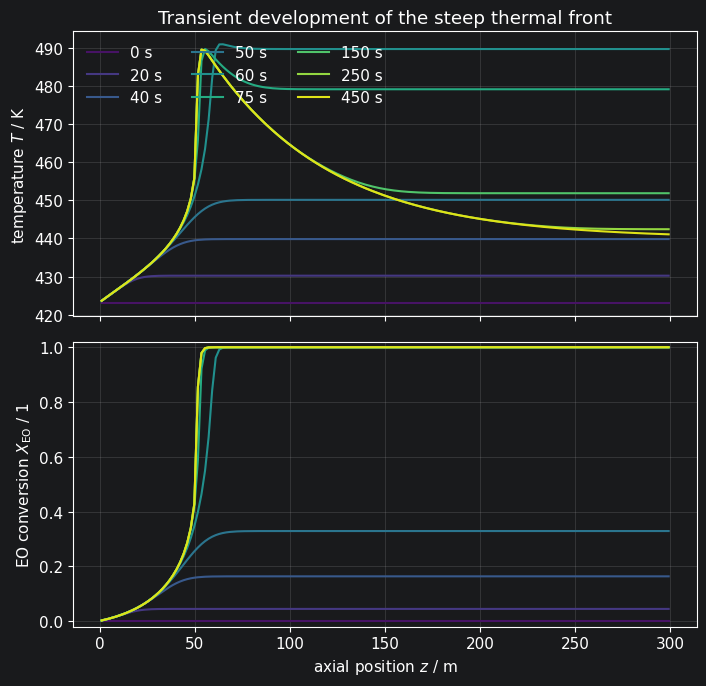

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 7.0), sharex=True)
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(times)))

for j, (t, color) in enumerate(zip(times, colors)):
    c = sol_steep.y[:p_steep.Nz, j]
    T = sol_steep.y[p_steep.Nz:, j]
    axes[0].plot(p_steep.z, T, color=color, label=f"{t:.0f} s")
    axes[1].plot(p_steep.z, 1.0 - c / p_steep.c_in, color=color)

axes[0].set_ylabel(r"temperature $T$ / K")
axes[0].legend(ncol=3, frameon=False)
axes[0].set_title("Transient development of the steep thermal front")
axes[1].set_xlabel(r"axial position $z$ / m")
axes[1].set_ylabel(r"EO conversion $X_{\mathrm{EO}}$ / 1")
axes[1].set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()


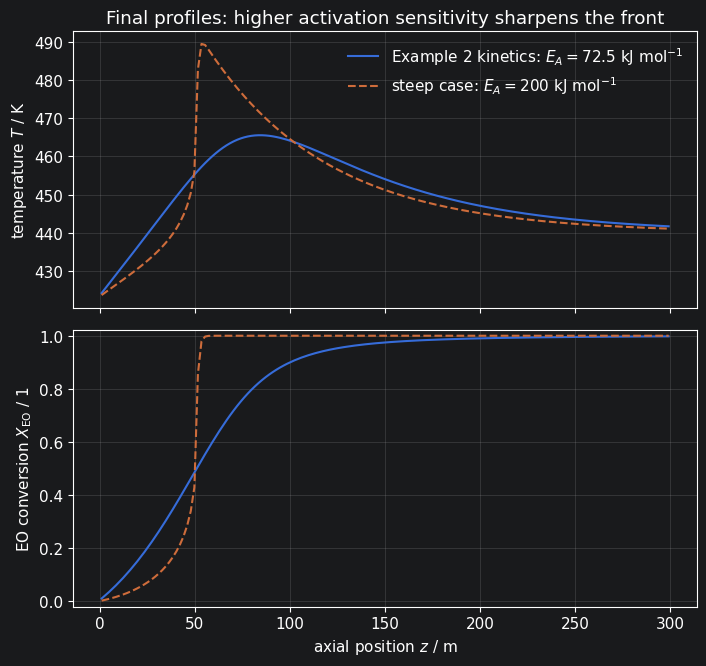

In [29]:
c_base = sol_base.y[:p_base.Nz, -1]
T_base = sol_base.y[p_base.Nz:, -1]
c_steep = sol_steep.y[:p_steep.Nz, -1]
T_steep = sol_steep.y[p_steep.Nz:, -1]

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.8), sharex=True)
axes[0].plot(p_base.z, T_base, label=r"Example 2 kinetics: $E_A=72.5$ kJ mol$^{-1}$")
axes[0].plot(p_steep.z, T_steep, "--", label=r"steep case: $E_A=200$ kJ mol$^{-1}$")
axes[1].plot(p_base.z, 1-c_base/p_base.c_in)
axes[1].plot(p_steep.z, 1-c_steep/p_steep.c_in, "--")
axes[0].set_ylabel(r"temperature $T$ / K")
axes[0].set_title("Final profiles: higher activation sensitivity sharpens the front")
axes[0].legend(frameon=False)
axes[1].set_xlabel(r"axial position $z$ / m")
axes[1].set_ylabel(r"EO conversion $X_{\mathrm{EO}}$ / 1")
axes[1].set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()


## 2 Grid convergence and numerical diffusion

First-order upwinding is monotone: it does not create spurious oscillations near a steep front. Its price is numerical diffusion, which broadens the front on coarse grids. The next calculation repeats the steep case on four uniform grids. The 10-90% conversion width is used as a simple front-thickness measure.


  Nz    dz / m    Tmax / K    10-90% width / m    nfev
  10    30.000     469.854              0.000    1224
  20    15.000     480.399             19.489    1046
  40     7.500     485.220             15.792    1080
  80     3.750     488.052             18.247    1013
 160     1.875     489.491             22.043     845
 320     0.938     490.157             23.624     696


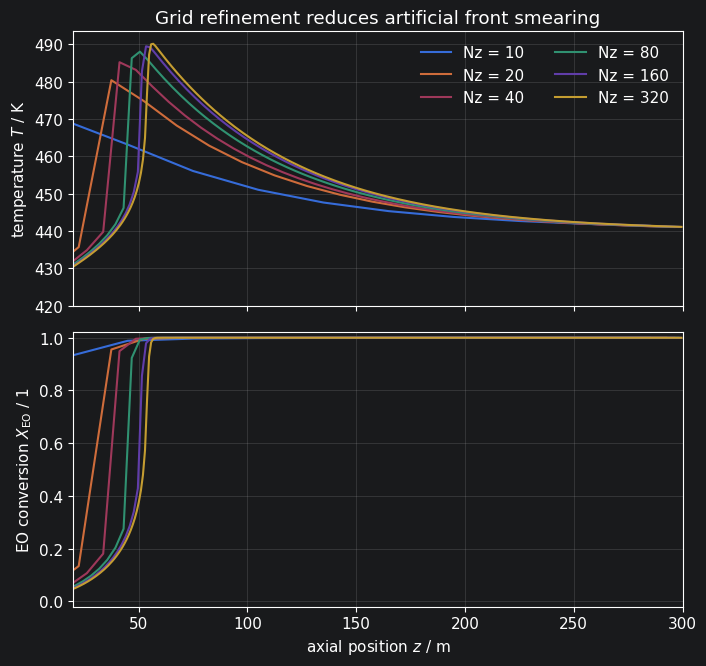

In [30]:
def front_width(z, conversion):
    z10 = np.interp(0.10, conversion, z)
    z90 = np.interp(0.90, conversion, z)
    return z90 - z10


grid_sizes = [10, 20, 40, 80, 160, 320]
grid_results = []

for Nz in grid_sizes:
    p = Parameters(Nz=Nz, EA=200.0e3)
    sol = simulate_1d(p, t_eval=[p.t_end])
    c = sol.y[:Nz, -1]
    T = sol.y[Nz:, -1]
    X = 1.0 - c / p.c_in
    grid_results.append((p, X, T, sol))

print("  Nz    dz / m    Tmax / K    10-90% width / m    nfev")
for p, X, T, sol in grid_results:
    print(f"{p.Nz:4d}  {p.dz:8.3f}  {T.max():10.3f}  {front_width(p.z, X):17.3f}  {sol.nfev:6d}")

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.8), sharex=True)
for p, X, T, sol in grid_results:
    axes[0].plot(p.z, T, label=f"Nz = {p.Nz}")
    axes[1].plot(p.z, X)
axes[0].set_ylabel(r"temperature $T$ / K")
axes[0].set_title("Grid refinement reduces artificial front smearing")
axes[0].legend(frameon=False, ncol=2)
axes[1].set_xlabel(r"axial position $z$ / m")
axes[1].set_ylabel(r"EO conversion $X_{\mathrm{EO}}$ / 1")
axes[1].set_xlim(20, 300)
axes[1].set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()


## 3 Local grid refinement in the reaction zone

Uniform refinement spends cells in the downstream region even though the steepest gradients occur in the first third of the reactor. A simple non-uniform grid can concentrate resolution where it is most useful:

- $0 \leq z \leq L_R/3$: the number of equal finite volumes is varied from 4 to 40;
- $L_R/3 < z \leq L_R$: exactly 8 equal finite volumes are retained for every case.

Because $L_R=300$ m, every downstream volume is 25 m long. The upstream volume length decreases from 25 m for 4 volumes to 2.5 m for 40 volumes. The same conservative upwind balance is used, with the local length $\Delta z_i$ in each control volume.


N upstream  N downstream  N total  dz upstream / m  dz downstream / m  Tmax / K
         4             8       12           25.000             25.000   474.701
         8             8       16           12.500             25.000   481.241
        24             8       32            4.167             25.000   487.252
        60             8       68            1.667             25.000   489.497
       100             8      108            1.000             25.000   490.140


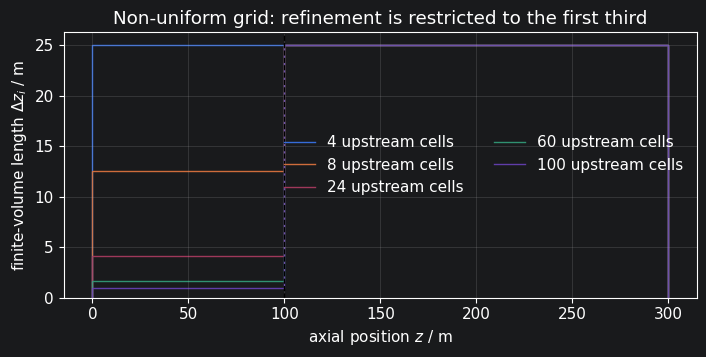

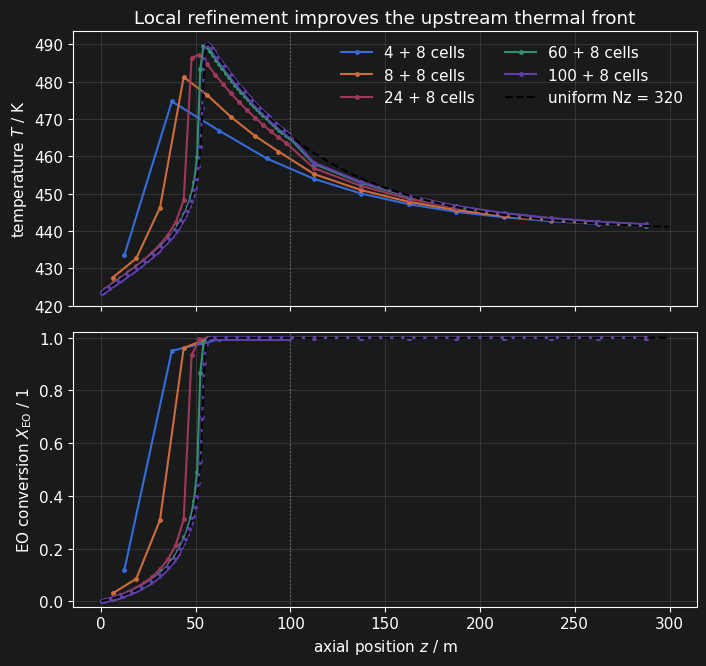

In [31]:
def make_nonuniform_parameters(Nz_upstream):
    Nz_downstream = 8
    p = Parameters(Nz=Nz_upstream + Nz_downstream, EA=200.e3)

    dz_upstream = np.full(Nz_upstream, (p.L/3.0) / Nz_upstream)
    dz_downstream = np.full(Nz_downstream, (2.0*p.L/3.0) / Nz_downstream)
    p.dz = np.r_[dz_upstream, dz_downstream]
    p.z_faces = np.r_[0.0, np.cumsum(p.dz)]
    p.z = 0.5 * (p.z_faces[:-1] + p.z_faces[1:])
    return p


upstream_grid_sizes = [4, 8, 24, 60, 100]
nonuniform_results = []

for Nz_upstream in upstream_grid_sizes:
    p_nonuniform = make_nonuniform_parameters(Nz_upstream)
    sol_nonuniform = simulate_1d(p_nonuniform, t_eval=[p_nonuniform.t_end])
    c = sol_nonuniform.y[:p_nonuniform.Nz, -1]
    T = sol_nonuniform.y[p_nonuniform.Nz:, -1]
    X = 1.0 - c / p_nonuniform.c_in
    nonuniform_results.append((Nz_upstream, p_nonuniform, X, T, sol_nonuniform))

print("N upstream  N downstream  N total  dz upstream / m  dz downstream / m  Tmax / K")
for Nz_upstream, p_nonuniform, X, T, sol_nonuniform in nonuniform_results:
    print(
        f"{Nz_upstream:10d}  {8:12d}  {p_nonuniform.Nz:7d}"
        f"  {p_nonuniform.dz[0]:15.3f}  {p_nonuniform.dz[-1]:17.3f}"
        f"  {T.max():8.3f}"
    )

fig, ax = plt.subplots(figsize=(7.2, 3.7))
for Nz_upstream, p_nonuniform, X, T, sol_nonuniform in nonuniform_results:
    ax.stairs(
        p_nonuniform.dz,
        p_nonuniform.z_faces,
        label=f"{Nz_upstream} upstream cells",
    )
ax.axvline(p_nonuniform.L/3.0, color="k", ls="--", lw=1)
ax.set_xlabel(r"axial position $z$ / m")
ax.set_ylabel(r"finite-volume length $\Delta z_i$ / m")
ax.set_title("Non-uniform grid: refinement is restricted to the first third")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

# The finest uniform result from the preceding block is used as a reference.
p_reference, X_reference, T_reference, _ = grid_results[-1]

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.8), sharex=True)
for Nz_upstream, p_nonuniform, X, T, sol_nonuniform in nonuniform_results:
    axes[0].plot(p_nonuniform.z, T, marker="o", ms=2.5,
                 label=f"{Nz_upstream} + 8 cells")
    axes[1].plot(p_nonuniform.z, X, marker="o", ms=2.5)

axes[0].plot(p_reference.z, T_reference, "k--", lw=1.5, label="uniform Nz = 320")
axes[1].plot(p_reference.z, X_reference, "k--", lw=1.5)
for ax in axes:
    ax.axvline(p_nonuniform.L/3.0, color="0.4", ls=":", lw=1)

axes[0].set_ylabel(r"temperature $T$ / K")
axes[0].set_title("Local refinement improves the upstream thermal front")
axes[0].legend(frameon=False, ncol=2)
axes[1].set_xlabel(r"axial position $z$ / m")
axes[1].set_ylabel(r"EO conversion $X_{\mathrm{EO}}$ / 1")
axes[1].set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()


The refinement improves the hotspot and conversion front with far fewer cells than the fine uniform grid. However, the eight fixed downstream volumes remain deliberately coarse. They are adequate for the slowly varying tail in this example, but this grid would be unsuitable if operating conditions moved the reaction zone beyond $L_R/3$.


## 4 Solver comparison

The method-of-lines system contains a fast reaction/temperature feedback and increasingly fast transport modes as the grid is refined. BDF is an implicit, variable-order method intended for stiff systems. RK45 can solve this particular case, but it needs more right-hand-side evaluations and becomes increasingly restricted by the smallest finite-volume residence time.


In [32]:
p_solver = Parameters(Nz=320, EA=200.0e3)
solver_results = []
for method in ["BDF", "BDF_jac_sparse", "RK45"]:
    sol = simulate_1d(p_solver, t_eval=[p_solver.t_end], method=method)
    solver_results.append((method, sol))

print("method   nfev   accepted output   wall time / s")
for method, sol in solver_results:
    print(f"{method:6s}  {sol.nfev:5d}          {len(sol.t):2d}          {sol.runtime:8.3f}")


method   nfev   accepted output   wall time / s
BDF       696           1             0.132
BDF_jac_sparse    696           1            57.355
RK45     3980           1             0.497


## Discussion

1. The model converges dynamically to the same type of axial profile obtained by spatial integration in Example 2, while also resolving startup and disturbances.
2. Increasing $E_A$ while preserving $k(440\,\mathrm{K})$ isolates the effect of stronger temperature sensitivity: heat release accelerates more abruptly and the reaction zone becomes narrower.
3. Coarse upwind grids remain stable and non-oscillatory but overpredict the front width. The refinement table makes this numerical diffusion visible.
4. The finite-volume formulation conserves the convective flux locally. For sharper fronts, a refined or non-uniform grid is preferable to tightening only the time-integration tolerances.
5. The BDF solver is a robust default for the stiff semi-discrete problem; the sparse dependency pattern avoids unnecessary dense linear algebra.
